# Notebook 3: Statistical Analysis 
This notebook performs statistical analysis on the video-level feature dataset (`video_level_valence_arousal_minmax.csv`).
We will explore behavioral and physiological indicators across different empathy scenes and analyze their relationship with self-reported valence and arousal labels.

# 1. Load Data

In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr
from sklearn.preprocessing import MinMaxScaler


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

INPUT_PATH = Path("video_level_valence_arousal_minmax.csv")

df = pd.read_csv(INPUT_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (384, 57)


In [176]:
def add_sig(ax, x1, x2, y, p, h=0.05):
    """
    ax = axis
    x1, x2 = positions of boxes
    y = base height
    p = p-value
    h = height offset
    """

    # bracket line
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.5,
        c="black"
    )

    # stars
    if p < 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        star = "ns"

    ax.text(
        (x1 + x2) / 2,
        y + h + 0.01,
        star,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

In [177]:
scene_order = [
    "empathy_scene_1",
    "empathy_scene_2",
    "empathy_scene_3",
    "empathy_scene_4"
]

scene_labels = ["Scene 1", "Scene 2", "Scene 3", "Scene 4"]

alpha_bonf = 0.05 / 6

# 2. Descriptive statistics

In [178]:
display( df.groupby("scene_name")[ ["target_valence","target_arousal"] ].agg(["mean","std","median"]) )

target_valence                  target_arousal            \
                          mean       std median           mean       std   
scene_name                                                                 
empathy_scene_1       2.968750  0.570376    3.0       2.302083  0.769413   
empathy_scene_2       2.614583  0.587050    3.0       2.156250  0.886485   
empathy_scene_3       0.770833  1.100040    1.0       1.145833  0.983861   
empathy_scene_4       3.041667  0.709584    3.0       2.364583  0.985364   

                        
                median  
scene_name              
empathy_scene_1    2.0  
empathy_scene_2    2.0  
empathy_scene_3    1.0  
empathy_scene_4    2.0

In [179]:
def run_friedman(feature):
    """
    Runs Friedman test for a given feature across scenes.
    Returns pivot table for post-hoc analysis.
    """
    pivot = (
        df.pivot(
            index="participant_id",
            columns="scene_name",
            values=feature
        )[scene_order]
        .dropna()
    )

    stat, p = friedmanchisquare(
        *[pivot[col] for col in scene_order]
    )

    print(f"{feature}: Friedman χ² = {stat:.3f}, p = {p:.5f}")

    return pivot

In [180]:
def run_pairwise_wilcoxon(feature):

    pivot = (
        df.pivot(
            index="participant_id",
            columns="scene_name",
            values=feature
        )[scene_order]
        .dropna()
    )

    results = []

    for s1, s2 in combinations(scene_order, 2):

        stat, p = wilcoxon(pivot[s1], pivot[s2])

        # effect size
        r = stat / np.sqrt(len(pivot))

        results.append([s1, s2, stat, p, r])

    res = pd.DataFrame(
        results,
        columns=["Scene 1", "Scene 2", "Statistic", "p", "effect_r"]
    )

    # ✔ Bonferroni correction
    reject, p_corr, _, _ = multipletests(res["p"], method="bonferroni")
    res["p_corrected"] = p_corr
    res["Significant"] = reject

    display(res)

    return res

In [181]:
def boxplot_feature(feature, title):

    plt.figure(figsize=(8,5))
    ax = plt.gca()

    sns.boxplot(
        x="scene_name",
        y=feature,
        data=df,
        order=scene_order,
        showfliers=False,
        ax=ax
    )

    plt.xticks(range(4), scene_labels)
    plt.title(title)

    pivot = df.pivot(
        index="participant_id",
        columns="scene_name",
        values=feature
    )[scene_order].dropna()

    y_max = pivot.max().max()
    step = y_max * 0.1

    pairs = list(combinations(scene_order, 2))

    for i, (s1, s2) in enumerate(pairs):

        stat, p = wilcoxon(pivot[s1], pivot[s2])

        # ❗ ONLY SIGNIFICANT RESULTS
        if p < 0.05:

            x1 = scene_order.index(s1)
            x2 = scene_order.index(s2)

            y = y_max + i * step

            add_sig(ax, x1, x2, y, p, h=step*0.3)

    plt.tight_layout()
    plt.show()

In [182]:
def barplot_feature(feature, title):

    means = df.groupby("scene_name")[feature].mean().reindex(scene_order)
    sem = df.groupby("scene_name")[feature].sem().reindex(scene_order)

    fig, ax = plt.subplots(figsize=(8,5))

    ax.bar(
        scene_labels,
        means,
        yerr=sem,
        capsize=5,
        color=['#2ecc71', '#f1c40f', '#e74c3c', '#3498db'],
        alpha=0.7,
        edgecolor='black'
    )

    ax.set_title(title,pad=20)
    ax.set_ylabel(feature)


    pivot = df.pivot(
        index="participant_id",
        columns="scene_name",
        values=feature
    )[scene_order].dropna()

    pairs = list(combinations(scene_order, 2))

    y_max = (means + sem).max()

    ax.set_ylim(0, y_max * 1.7)

    step = y_max * 0.15  


    for i, (s1, s2) in enumerate(pairs):

        stat, p = wilcoxon(pivot[s1], pivot[s2])

        if p < 0.05:

            x1 = scene_order.index(s1)
            x2 = scene_order.index(s2)

            y = y_max + (i * step)

            add_sig(ax, x1, x2, y, p, h=step * 0.3)

    plt.tight_layout()
    plt.show()


# 3. Analysis with Friedman and Wilcoxon test

VALENCE ANALYSIS
target_valence: Friedman χ² = 201.165, p = 0.00000


,Scene 1,Scene 2,Statistic,p,effect_r,p_corrected,Significant
0,empathy_scene_1,empathy_scene_2,319.0,2.239146e-05,32.557801,1.343488e-04,True
1,empathy_scene_1,empathy_scene_3,95.0,1.912753e-16,9.695897,1.147652e-15,True
2,empathy_scene_1,empathy_scene_4,308.0,3.145382e-01,31.435118,1.000000e+00,False
3,empathy_scene_2,empathy_scene_3,104.5,1.555445e-15,10.665487,9.332668e-15,True
4,empathy_scene_2,empathy_scene_4,285.0,1.252014e-05,29.087691,7.512081e-05,True
5,empathy_scene_3,empathy_scene_4,92.0,8.273723e-16,9.389711,4.964234e-15,True


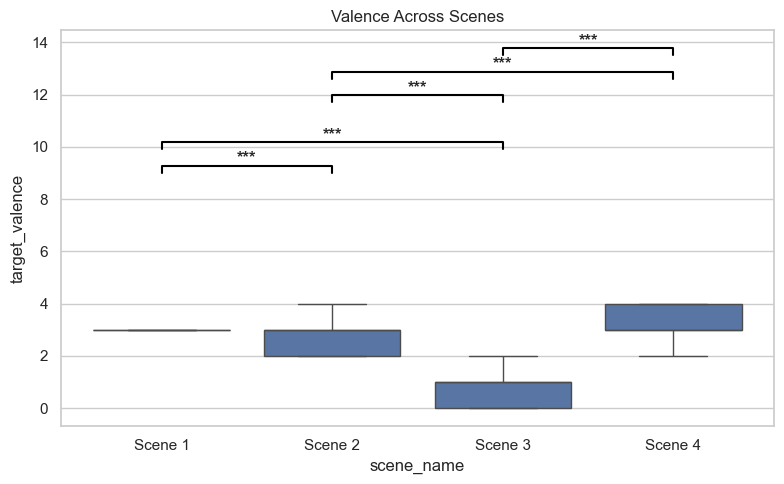

In [183]:
print("VALENCE ANALYSIS")

run_friedman("target_valence")
run_pairwise_wilcoxon("target_valence")

boxplot_feature("target_valence", "Valence Across Scenes")

AROUSAL ANALYSIS
target_arousal: Friedman χ² = 83.388, p = 0.00000


,Scene 1,Scene 2,Statistic,p,effect_r,p_corrected,Significant
0,empathy_scene_1,empathy_scene_2,805.0,1.343049e-01,82.159968,8.058294e-01,False
1,empathy_scene_1,empathy_scene_3,279.0,3.012344e-11,28.475318,1.807406e-10,True
2,empathy_scene_1,empathy_scene_4,766.5,6.125956e-01,78.230579,1.000000e+00,False
3,empathy_scene_2,empathy_scene_3,369.0,2.438967e-09,37.660905,1.463380e-08,True
4,empathy_scene_2,empathy_scene_4,761.5,1.117896e-01,77.720268,6.707379e-01,False
5,empathy_scene_3,empathy_scene_4,266.0,3.566643e-11,27.148511,2.139986e-10,True


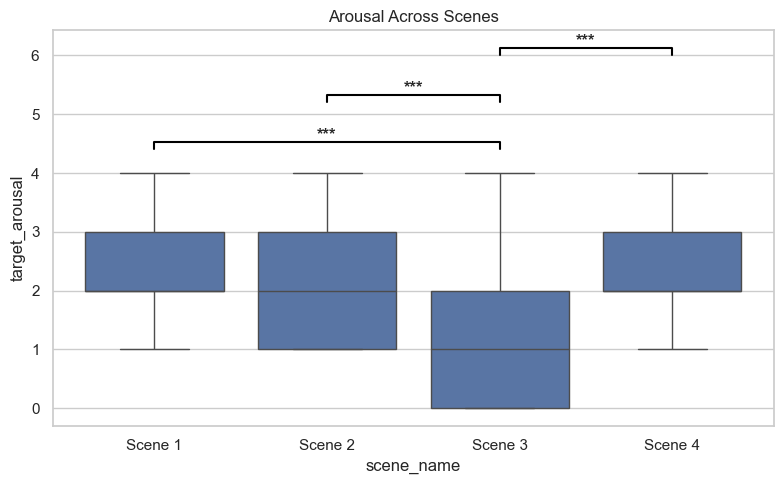

In [184]:
print("AROUSAL ANALYSIS")

run_friedman("target_arousal")
run_pairwise_wilcoxon("target_arousal")

boxplot_feature("target_arousal", "Arousal Across Scenes")

In [185]:
selected_features = [
    "breathingrate_breathingrate_min",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "hrv_hrv_rr_max",
    "expression_smile_intensity_max",
    "facialactivation_facialactivation_max"
]

breathingrate_breathingrate_min
breathingrate_breathingrate_min: Friedman χ² = 9.417, p = 0.02423


,Scene 1,Scene 2,Statistic,p,effect_r,p_corrected,Significant
0,empathy_scene_1,empathy_scene_2,1869.0,0.127116,191.755354,0.762696,False
1,empathy_scene_1,empathy_scene_3,1752.0,0.050012,179.751407,0.300072,False
2,empathy_scene_1,empathy_scene_4,1339.0,0.000478,137.378501,0.002867,True
3,empathy_scene_2,empathy_scene_3,2198.0,0.760844,225.510042,1.000000,False
4,empathy_scene_2,empathy_scene_4,1863.0,0.121660,191.139767,0.729957,False
5,empathy_scene_3,empathy_scene_4,1959.0,0.233455,200.989159,1.000000,False


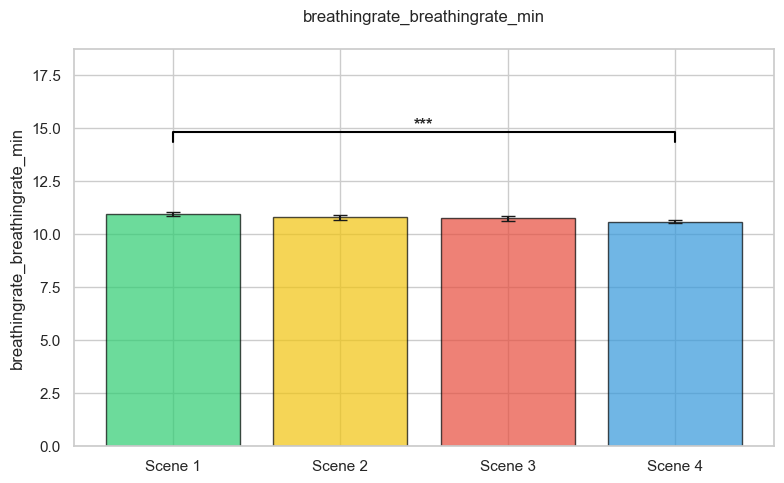

emgactivation_emg_amplitude_zygo_weighted_max
emgactivation_emg_amplitude_zygo_weighted_max: Friedman χ² = 67.025, p = 0.00000


,Scene 1,Scene 2,Statistic,p,effect_r,p_corrected,Significant
0,empathy_scene_1,empathy_scene_2,2228.0,7.147896e-01,227.394298,1.000000e+00,False
1,empathy_scene_1,empathy_scene_3,805.0,2.613788e-08,82.159968,1.568273e-07,True
2,empathy_scene_1,empathy_scene_4,1118.0,9.792007e-06,114.105397,5.875204e-05,True
3,empathy_scene_2,empathy_scene_3,589.0,2.086349e-10,60.114561,1.251809e-09,True
4,empathy_scene_2,empathy_scene_4,909.0,2.154742e-07,92.774424,1.292845e-06,True
5,empathy_scene_3,empathy_scene_4,1826.0,6.658514e-02,186.365345,3.995109e-01,False


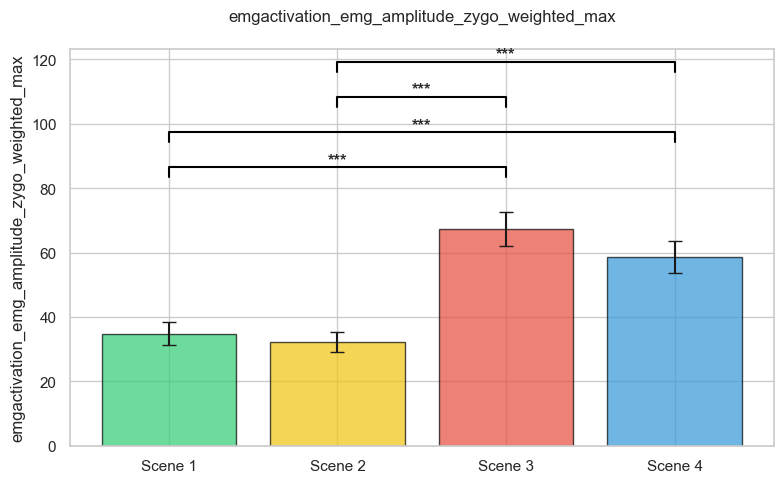

hrv_hrv_rr_max
hrv_hrv_rr_max: Friedman χ² = 2.740, p = 0.43346


,Scene 1,Scene 2,Statistic,p,effect_r,p_corrected,Significant
0,empathy_scene_1,empathy_scene_2,1988.0,0.214065,202.899400,1.000000,False
1,empathy_scene_1,empathy_scene_3,1931.0,0.195169,197.081862,1.000000,False
2,empathy_scene_1,empathy_scene_4,2139.0,0.489776,218.310773,1.000000,False
3,empathy_scene_2,empathy_scene_3,1567.0,0.008132,159.931268,0.048790,True
4,empathy_scene_2,empathy_scene_4,2252.0,0.781221,229.843788,1.000000,False
5,empathy_scene_3,empathy_scene_4,1848.5,0.079732,188.661741,0.478392,False


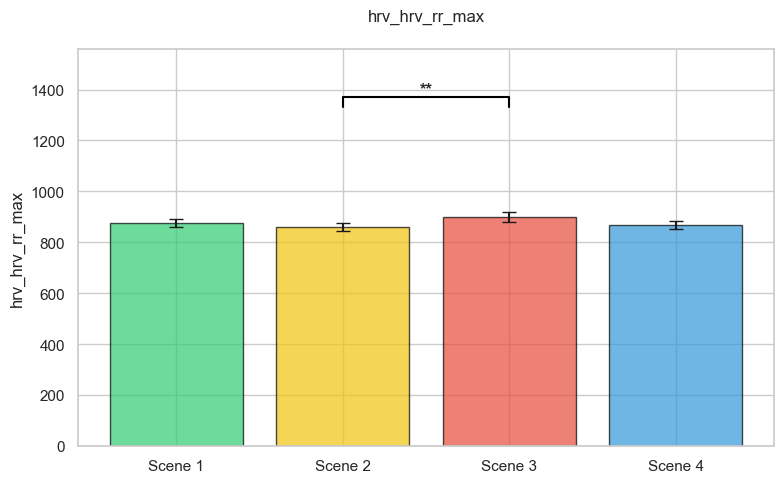

expression_smile_intensity_max
expression_smile_intensity_max: Friedman χ² = 70.323, p = 0.00000


,Scene 1,Scene 2,Statistic,p,effect_r,p_corrected,Significant
0,empathy_scene_1,empathy_scene_2,261.0,2.579872e-01,26.638201,1.000000e+00,False
1,empathy_scene_1,empathy_scene_3,397.0,7.495574e-07,40.518643,4.497344e-06,True
2,empathy_scene_1,empathy_scene_4,361.5,1.308980e-04,36.895439,7.853880e-04,True
3,empathy_scene_2,empathy_scene_3,161.0,2.464520e-10,16.431994,1.478712e-09,True
4,empathy_scene_2,empathy_scene_4,207.0,5.141646e-07,21.126849,3.084988e-06,True
5,empathy_scene_3,empathy_scene_4,993.0,7.164660e-02,101.347638,4.298796e-01,False


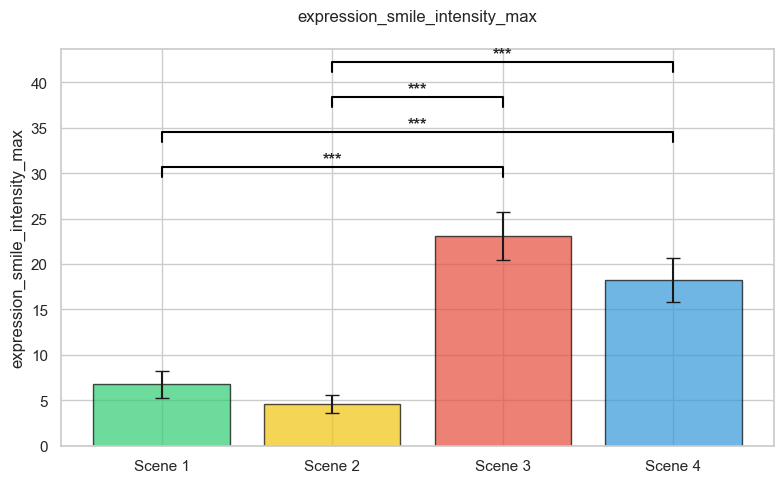

facialactivation_facialactivation_max
facialactivation_facialactivation_max: Friedman χ² = 52.738, p = 0.00000


,Scene 1,Scene 2,Statistic,p,effect_r,p_corrected,Significant
0,empathy_scene_1,empathy_scene_2,2207.0,6.583650e-01,225.250994,1.000000e+00,False
1,empathy_scene_1,empathy_scene_3,922.0,2.777355e-07,94.101231,1.666413e-06,True
2,empathy_scene_1,empathy_scene_4,1207.0,4.194753e-05,123.188922,2.516852e-04,True
3,empathy_scene_2,empathy_scene_3,826.0,4.047311e-08,84.303272,2.428387e-07,True
4,empathy_scene_2,empathy_scene_4,949.0,4.672508e-07,96.856907,2.803505e-06,True
5,empathy_scene_3,empathy_scene_4,1937.0,1.530515e-01,197.694235,9.183091e-01,False


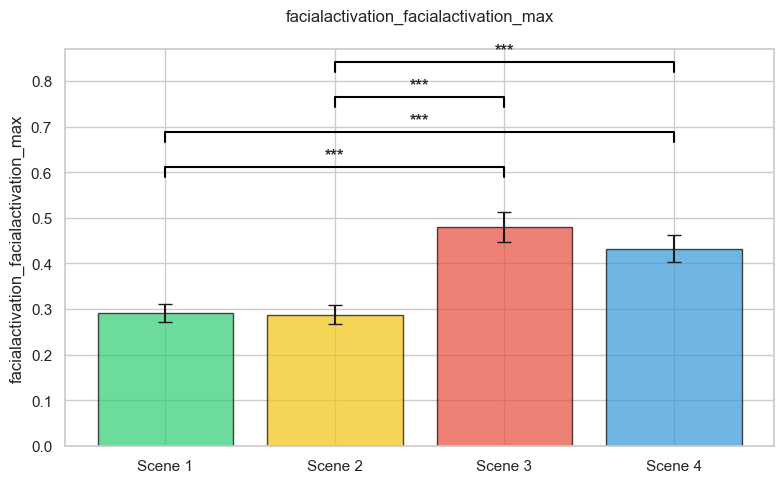

In [186]:
for feat in selected_features:
    print(feat)

    run_friedman(feat)
    run_pairwise_wilcoxon(feat)

    barplot_feature(feat, feat)

In [187]:
corr_features = [
    "target_valence",
    "target_arousal",
    "breathingrate_breathingrate_min",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "hrv_hrv_rr_max",
    "expression_smile_intensity_max",
    "facialactivation_facialactivation_max"
]

corr_matrix = df[corr_features].corr(method="spearman")

print("SPEARMAN CORRELATION MATRIX")
display(corr_matrix.round(3))

SPEARMAN CORRELATION MATRIX


,target_valence,target_arousal,breathingrate_breathingrate_min,emgactivation_emg_amplitude_zygo_weighted_max,hrv_hrv_rr_max,expression_smile_intensity_max,facialactivation_facialactivation_max
target_valence,1.000,0.559,0.030,-0.170,-0.039,-0.232,-0.112
target_arousal,0.559,1.000,-0.031,-0.052,0.031,-0.083,-0.012
breathingrate_breathingrate_min,0.030,-0.031,1.000,-0.120,0.242,-0.132,-0.089
emgactivation_emg_amplitude_zygo_weighted_max,-0.170,-0.052,-0.120,1.000,0.054,0.677,0.790
hrv_hrv_rr_max,-0.039,0.031,0.242,0.054,1.000,0.149,0.083
expression_smile_intensity_max,-0.232,-0.083,-0.132,0.677,0.149,1.000,0.493
facialactivation_facialactivation_max,-0.112,-0.012,-0.089,0.790,0.083,0.493,1.000


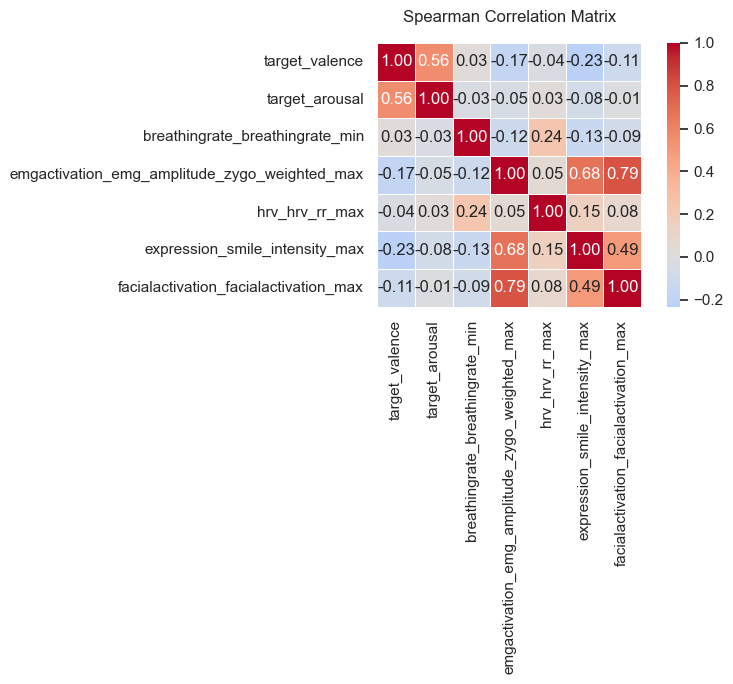

In [188]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix", pad=15)
plt.tight_layout()
plt.show()

In [189]:
print("CORRELATION WITH AROUSAL")

for feat in corr_features[2:]:
    r, p = spearmanr(df[feat], df["target_arousal"])
    print(f"{feat}: rho = {r:.3f}, p = {p:.5f}")

CORRELATION WITH AROUSAL
breathingrate_breathingrate_min: rho = nan, p = nan
emgactivation_emg_amplitude_zygo_weighted_max: rho = -0.052, p = 0.31106
hrv_hrv_rr_max: rho = 0.031, p = 0.53889
expression_smile_intensity_max: rho = -0.083, p = 0.10527
facialactivation_facialactivation_max: rho = -0.012, p = 0.81853


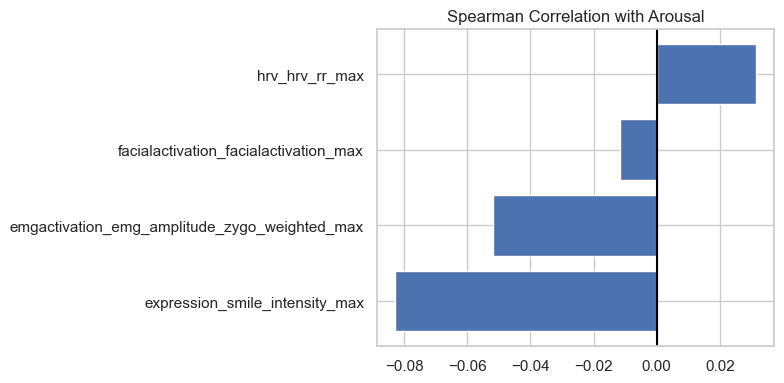

In [191]:
results = []

for feat in corr_features[2:]:
    r, p = spearmanr(df[feat], df["target_arousal"])

    results.append({
        "Feature": feat,
        "rho": r,
        "p": p
    })

corr_df = pd.DataFrame(results)
corr_df = corr_df.sort_values("rho")

plt.figure(figsize=(8,4))

plt.barh(corr_df["Feature"], corr_df["rho"])

plt.axvline(0, color="black")
plt.title("Spearman Correlation with Arousal")
plt.tight_layout()
plt.show()

# 4. Combined Valence + Arousal Score

In [ ]:
def compute_combined_score():
    scaler = MinMaxScaler()

    df[["valence_norm", "arousal_norm"]] = scaler.fit_transform(
        df[["target_valence", "target_arousal"]]
    )

    df["valence_arousal_score"] = (
        0.5 * df["valence_norm"] +
        0.5 * df["arousal_norm"]
    )

    return df

In [198]:
df = compute_combined_score()

In [ ]:
def scene_ranking_combined(title="Combined Valence-Arousal Score"):

    stats = (
        df.groupby("scene_name")["valence_arousal_score"]
        .agg(["mean", "std"])
        .reindex(scene_order)
        .sort_values("mean", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10,6))  

    ax.bar(
        stats.index,
        stats["mean"],
        yerr=stats["std"],
        capsize=6,
        alpha=0.85,
        edgecolor="black"
    )

    ax.set_title(title, pad=18)
    ax.set_ylabel("Combined Score")

    y_max = stats["mean"].max()
    ax.set_ylim(0, y_max * 1.45)

    x_offset = 0.18
    y_offset = y_max * 0.03

    for i, (scene, row) in enumerate(stats.iterrows()):
        ax.text(
            i + x_offset,                 
            row["mean"] + y_offset,       
            f"#{i+1}",
            ha="left",
            va="center",
            fontsize=13,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

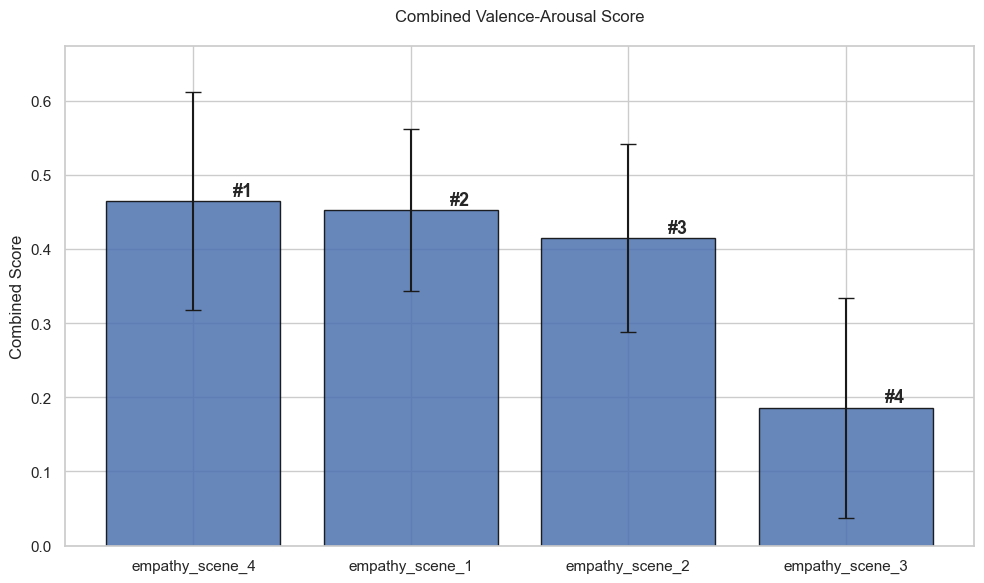

In [206]:
scene_ranking_combined()